## Research Objective

- Target variable: `fare_amount`
- Evaluation Matrix: RMSE (root mean-squared error)
- Baseline Model: mean `fare_amount` from the training set which is $11.35

## Data Wrangling

### Data Collection


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import iqr,norm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge,Lasso
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error,r2_score
from sklearn.model_selection import train_test_split,KFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
sns.set_theme(palette="viridis",rc={"figure.figsize": (8, 5)},style="darkgrid")

In [2]:
# Loading only one million train rows for due to local memory limits
train = pd.read_csv('data.nosync/train.csv', nrows=1000000)
test = pd.read_csv('data.nosync/test.csv')

## Data Cleaning

In [3]:
print("--- Descriptive Summary ---")
print(train.describe())
print("--- Data Types ---")
print(train.dtypes)
print("--- Missing Values ---")
print(train.isna().sum())

--- Descriptive Summary ---
          fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  1000000.000000    1000000.000000   1000000.000000      999990.000000   
mean        11.348079        -72.526640        39.929008         -72.527860   
std          9.822090         12.057937         7.626154          11.324494   
min        -44.900000      -3377.680935     -3116.285383       -3383.296608   
25%          6.000000        -73.992060        40.734965         -73.991385   
50%          8.500000        -73.981792        40.752695         -73.980135   
75%         12.500000        -73.967094        40.767154         -73.963654   
max        500.000000       2522.271325      2621.628430          45.581619   

       dropoff_latitude  passenger_count  
count     999990.000000   1000000.000000  
mean          39.919954         1.684924  
std            8.201418         1.323911  
min        -3114.338567         0.000000  
25%           40.734046         1.000000  
50

# Exploratory Data Analysis (EDA)

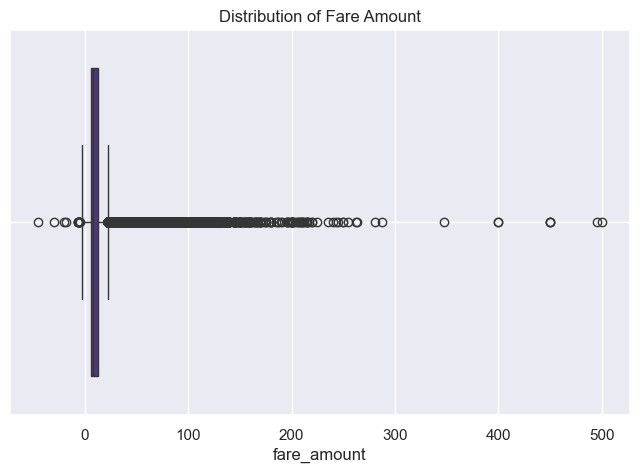

In [4]:
sns.boxplot(x="fare_amount",data=train)
plt.title("Distribution of Fare Amount")
plt.grid(axis="y")
plt.show()

In [5]:
print(f"99% Quantile: {train["fare_amount"].quantile(0.99)}\nMedian: \
{train["fare_amount"].median()}")
print(train["fare_amount"].value_counts(bins=[0,50,100,150,200]))

99% Quantile: 52.33
Median: 8.5
(-0.001, 50.0]    987191
(50.0, 100.0]      12375
(100.0, 150.0]       288
(150.0, 200.0]        70
Name: count, dtype: int64


- Top 1% fare is 52.33 whereas median fare is 8.5.
- To keep balance between extreme outliers and robustness I will keep upper limit to 100 because there are 12375 records between 50 and 100. Also removing negative values.

In [6]:
def missing_outliers(df):
    # 1.Creating a clone for reporducibility
    df_clean = df.copy()
    # 2. Dropping Missing values
    columns_to_drop = ["dropoff_longitude","dropoff_latitude"]
    df_clean = df_clean.dropna(subset=columns_to_drop)
    # 3. Removing negative prices
    df_clean= df_clean[df_clean['fare_amount']>0]
    # 4. Removing outliers by quantile method
    df_clean = df_clean[df_clean['fare_amount']<100]
    return df_clean.reset_index(drop=True)
train_clean = missing_outliers(train)

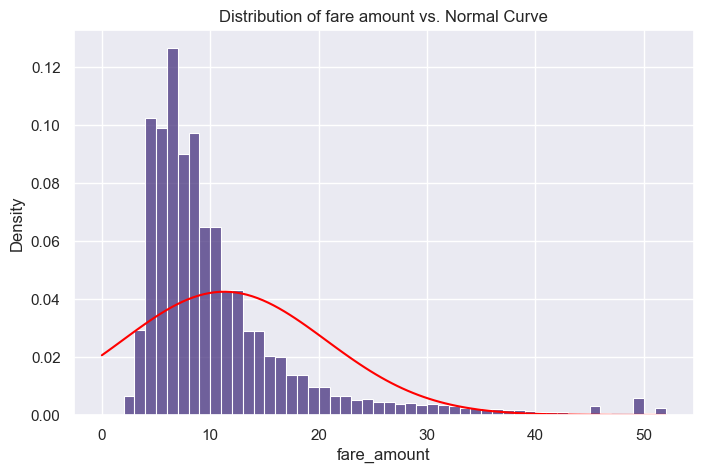

In [7]:
sns.histplot(x="fare_amount",bins=np.linspace(0,52,53),stat="density",data=train_clean)
x_smooth = np.linspace(0,52,106)
normal_dist= norm.pdf(x_smooth,train_clean['fare_amount'].mean(),train_clean['fare_amount'].std())
plt.plot(x_smooth,normal_dist,color="red")
plt.title("Distribution of fare amount vs. Normal Curve")
plt.show()

- Distribution of Fare amount shows it is right-skewed with highest frequency in the price range of $6-7.

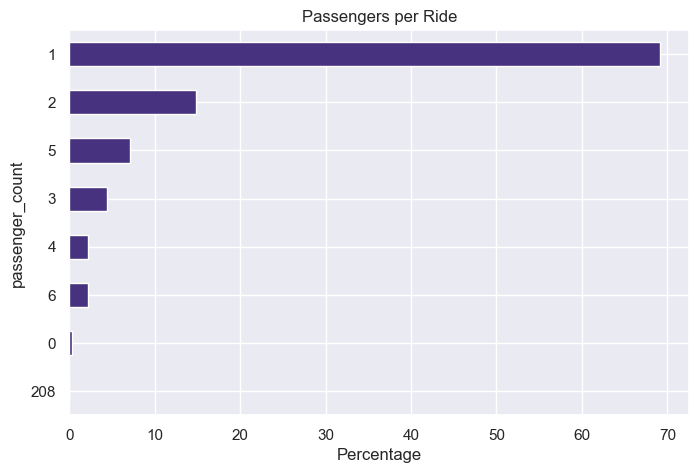

In [8]:
(train_clean["passenger_count"].value_counts(normalize=True,ascending=True)*100).plot(kind="barh")
plt.title("Passengers per Ride")
plt.xlabel("Percentage")
plt.show()

In [9]:
print(f"Number of rows with either 0 and one instance of 208 passengers are : \
{len(train_clean[train_clean['passenger_count'].isin([208,0])])}\n")
train_clean=train_clean[~train_clean["passenger_count"].isin([208,0])]

Number of rows with either 0 and one instance of 208 passengers are : 3556



In [10]:
# Updating missing_outliers function to remove impossible passenger value
def missing_outliers(df):
    # 1.Creating a clone for reporducibility
    df_clean = df.copy()
    # 2. Dropping Missing values
    columns_to_drop = ["dropoff_longitude","dropoff_latitude"]
    df_clean = df_clean.dropna(subset=columns_to_drop)
    # 3. Removing negative prices
    df_clean= df_clean[df_clean['fare_amount']>0]
    # 4. Removing outliers by quantile method
    df_clean = df_clean[df_clean['fare_amount']<100]
    #5. Remoming the extreme passenger count
    df_clean = df_clean[~df_clean["passenger_count"].isin([208,0])]
    return train_clean.reset_index(drop=True)
train_clean = missing_outliers(train)

In [11]:
def date_transform(df):
    df_clean=df.copy()
    df_clean["pickup_datetime"]=pd.to_datetime( df_clean["pickup_datetime"],errors="coerce")
    df_clean["hour"]=df_clean["pickup_datetime"].dt.hour
    df_clean["year"]=df_clean["pickup_datetime"].dt.year
    df_clean["day_of_week"]=df_clean["pickup_datetime"].dt.day_of_week
    return df_clean
train_clean=date_transform(train_clean)

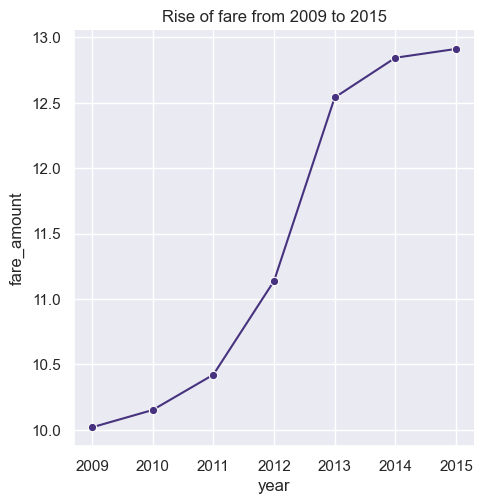

In [12]:
sns.relplot(x="year",y="fare_amount",data=train_clean,kind="line",marker="o",errorbar=None)
plt.title("Rise of fare from 2009 to 2015")
plt.show()

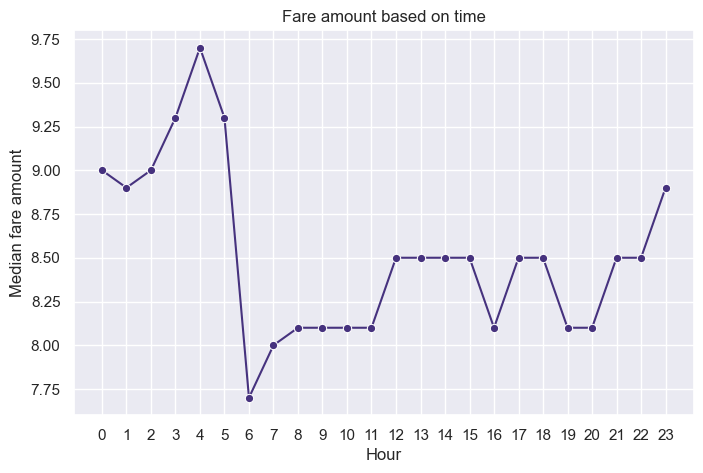

In [13]:
sns.lineplot(x="hour",y="fare_amount",data=train_clean,estimator="median",marker="o",errorbar=None)
plt.xlabel('Hour')
plt.ylabel('Median fare amount')
plt.xticks(range(24))
plt.title('Fare amount based on time')
plt.show()

In [14]:
def coordinate_outlier(df):
    """
        Filtering the langitute between Staten Island to Yonkers
        and longitude between New Jersey to JFK/Queens
       """
    df_clean = df.copy()
    latitute_range = (40.5, 41.0) 
    longitude_range = (-74.3, -73.7)
    co_ordinates_boundary = df_clean["pickup_latitude"].between(*latitute_range)&\
                          df_clean['dropoff_latitude'].between(*latitute_range)&\
                          df_clean['pickup_longitude'].between(*longitude_range)&\
                          df_clean['dropoff_longitude'].between(*longitude_range)
    df_clean = df_clean[co_ordinates_boundary]
    return df_clean.reset_index(drop=True)
train_clean = coordinate_outlier(train_clean)

In [15]:
def haversign_distance(df):
    """
    d = 2R · arcsin( √[ sin²((lat₂ - lat₁)/2) + cos(lat₁)·cos(lat₂)·sin²((lon₂ - lon₁)/2) ] )
    6371 is earth radius in Km
    """
    df_clean=df.copy()
    lat1=np.radians(df_clean['pickup_latitude'])
    lat2=np.radians(df_clean['dropoff_latitude'])
    lon1=np.radians(df_clean['pickup_longitude'])
    lon2=np.radians(df_clean['dropoff_longitude'])
    dlat= lat2-lat1
    dlon= lon2-lon1
    # Haversine formula
    a= np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c= 2 * np.arcsin(np.sqrt(a))
    R=6371
    df_clean["distance_km"]=c*R
    return df_clean
train_clean=haversign_distance(train_clean)

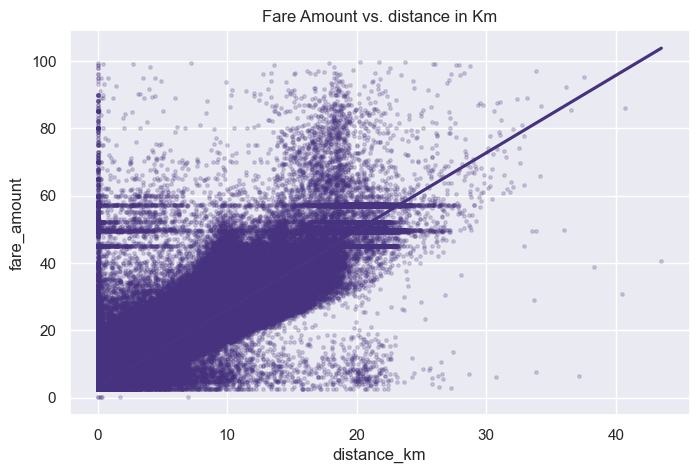

In [16]:
sns.regplot(x="distance_km",y="fare_amount",scatter_kws={"alpha":0.2,"s":6},data=train_clean)
plt.title("Fare Amount vs. distance in Km")
plt.show()

- The regression plot of distance vs fare explained linear model is not suitable for the dataset as there are flat lines near 50-60 fare range.
- Distance is not the only factor for fare as we see near the y axis fare rise while the distance covered is 0. Time and location factors are also need to be considered.

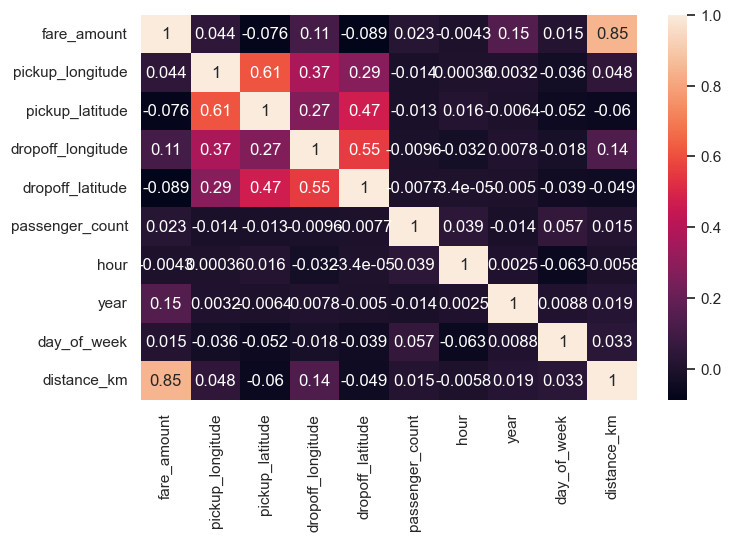

In [17]:
sns.heatmap(train_clean.corr(numeric_only=True,method="spearman"),annot=True)
plt.show()

- As the data sets has non-linear relation, using spearman co-relations shows Fare has most positive co-relation with distance followed by year, dropoff_longitude, pickup_longitude, day_of_week, passenger_count, day_of_week respectively.

## Modelling
### Base-line model

In [18]:
# 1. Feature selection
X=train_clean[["distance_km","dropoff_longitude","pickup_longitude","day_of_week"\
               ,"passenger_count","year","hour"]]

# 2. Target selection
y=train_clean["fare_amount"]

# 3. 20% as test set/unseen data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 4. Robust scaling due to extreme outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 4. Looping 3 linear model for comparison
models= {"Linear Regression": LinearRegression(),
         "Ridge Regression": Ridge(random_state=42),
         "XGBRegressor": XGBRegressor(random_state=42,objective="reg:squarederror",n_estimators=100)}
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    rmse= root_mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    print(f"Model: {name}\nRMSE: {rmse:.2f} R2: {r2:.2f}")

Model: Linear Regression
RMSE: 4.28 R2: 0.78
Model: Ridge Regression
RMSE: 4.28 R2: 0.78
Model: XGBRegressor
RMSE: 3.50 R2: 0.86


- A robust machine learning pipeline was implemented, beginning with an 80/20 train-test split. To mitigate the impact of outliers in the NYC taxi dataset, a RobustScaler was applied. Out of three Baseline model XGBRegressor has lowest RMSE and highest R2. 

## Hyperparemeter tuninng with K-Fold cross validation for best baseline model

In [19]:
# 1. Cross validation with 5 split for robustness and to reduce biasness
kfold=KFold(n_splits=5,shuffle=True,random_state=42)

# 2. hyperparameter tuning of Ridge regression parameters: alpha and solver to penalize large co-efficients
xgb=XGBRegressor(random_state=42,objective="reg:squarederror") # fixed seed for reproducibility
param_gid={"n_estimators":[200,300],"max_depth":[3,5],"learning_rate":[0.01,0.1]} #lsqr for faster iteration and saga for gradient decent

# 3. Randomized Seach of all 8 parameter combinations across 5 splits (total 40 fits)
xgb_gridcv=RandomizedSearchCV(xgb,param_gid,cv=kfold,n_iter=8)

# 4. Fitting and predicting using the best estimator and parameters
xgb_gridcv.fit(X_train_scaled,y_train)
y_pred=xgb_gridcv.predict(X_test_scaled)

# 5. Results
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Tuned Parameters for the best estimator:{xgb_gridcv.best_params_}\nMean Score of the best estimator:{xgb_gridcv.best_score_}")
print(f"Local Validation RMSE: {rmse:.2f}\nR2 Score: {xgb_gridcv.score(X_test_scaled,y_test):.2f}")

Tuned Parameters for the best estimator:{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
Mean Score of the best estimator:0.8510895091453824
Local Validation RMSE: 3.51
R2 Score: 0.85


- Model hyperparameters are optimized using a Randomized Search with 5-fold Cross-Validation for total 40 model fits of selected 8 parameters combinations to a single training instance to ensure no overfittings.
- The RMSE of 3.59 means on average predictions are off by $3.59.
- R2 Score of 0.85 means, the seleted features explain 85% of the variance in the fare amount.

### Feature Importance

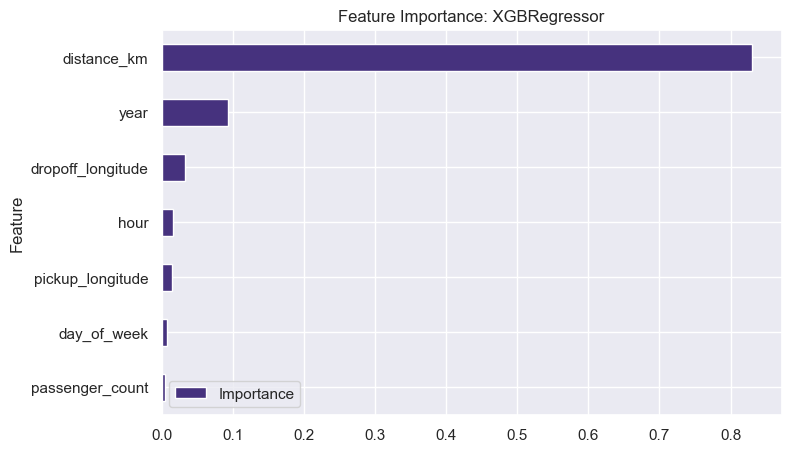

In [20]:
pd.DataFrame({"Feature":X.columns,"Importance":xgb_gridcv.best_estimator_.feature_importances_}).sort_values(by="Importance")\
    .plot.barh("Feature","Importance")
plt.title("Feature Importance: XGBRegressor")
plt.show()

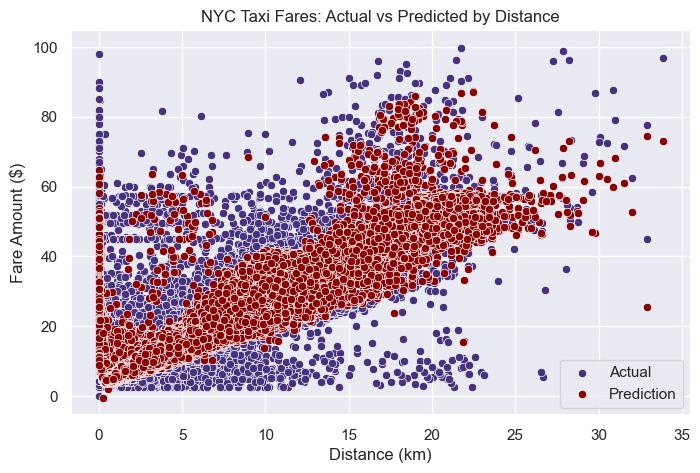

In [21]:
sns.scatterplot(x=X_test["distance_km"],y=y_test,label="Actual")
sns.scatterplot(x=X_test["distance_km"],y=y_pred,label="Prediction",color="darkred")
plt.title("NYC Taxi Fares: Actual vs Predicted by Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.show()

- The scatter plot shows the XGBoost model captures the some non-linear relationship between distance and fare, while fail to captute  noise like base base fare, short distance. Need more location based features.

## Kaggle Submission

In [24]:
test=date_transform(test)
test=haversign_distance(test)
X_scaled= scaler.fit_transform(X)
xgb_gridcv.fit(X_scaled,y=train_clean["fare_amount"])
test_features = test[["distance_km","dropoff_longitude","pickup_longitude","day_of_week"\
               ,"passenger_count","year","hour"]]
test_features_scaled=scaler.transform(test_features)
test["fare_amount"] = xgb_gridcv.predict(test_features_scaled)
test[["key","fare_amount"]].to_csv('submission.csv', index=False)
print("Final Submission Generated!")

Final Submission Generated!
